In [2]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

In [3]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

In [4]:
train_dataset = datasets.ImageFolder(
    "dataset_split/train",
    transform=transform
)

test_dataset = datasets.ImageFolder(
    "dataset_split/test",
    transform=transform
)

In [8]:
batch_size = 4

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [9]:
classes = train_dataset.classes
print(classes)

['Drowsy', 'Non_Drowsy']


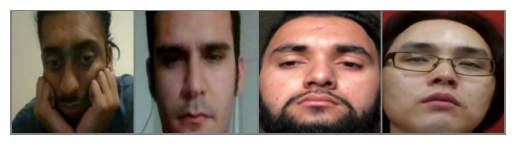

Labels: ['Drowsy', 'Non_Drowsy', 'Drowsy', 'Drowsy']


In [10]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print("Labels:", [classes[l] for l in labels])

In [11]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(6, 16, 5)

        self.fc1 = nn.Linear(16 * 29 * 29, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 2)  # 2 klase

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        x = self.fc3(x)
        return x

In [12]:
net = CNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [13]:
epochs = 5

for epoch in range(epochs):
    running_loss = 0.0

    for inputs, labels in train_loader:

        outputs = net(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoha {epoch+1}, loss: {running_loss/len(train_loader):.3f}")

Epoha 1, loss: 0.055
Epoha 2, loss: 0.004
Epoha 3, loss: 0.001
Epoha 4, loss: 0.001
Epoha 5, loss: 0.000


In [14]:
net.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:

        outputs = net(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

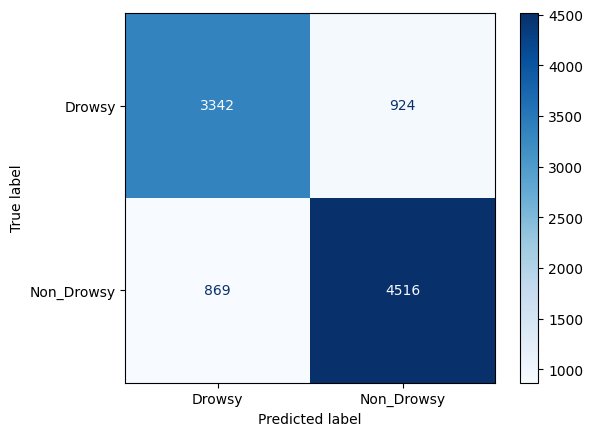

In [15]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(cm, display_labels=classes)
disp.plot(cmap="Blues")
plt.show()

In [16]:
print("Accuracy:", accuracy_score(all_labels, all_preds))

print(classification_report(all_labels, all_preds, target_names=classes))

Accuracy: 0.8142161434048285
              precision    recall  f1-score   support

      Drowsy       0.79      0.78      0.79      4266
  Non_Drowsy       0.83      0.84      0.83      5385

    accuracy                           0.81      9651
   macro avg       0.81      0.81      0.81      9651
weighted avg       0.81      0.81      0.81      9651

